## Análisis Exploratorio de Datos (EDA)

Antes de construir features y entrenar el modelo, exploramos el comportamiento de usuarios,
apuestas, eventos y transacciones mediante joins entre las tablas normalizadas.

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

DB = "workspace.apuestas_db"
sns.set_style("whitegrid")

Distribución del saldo de usuarios

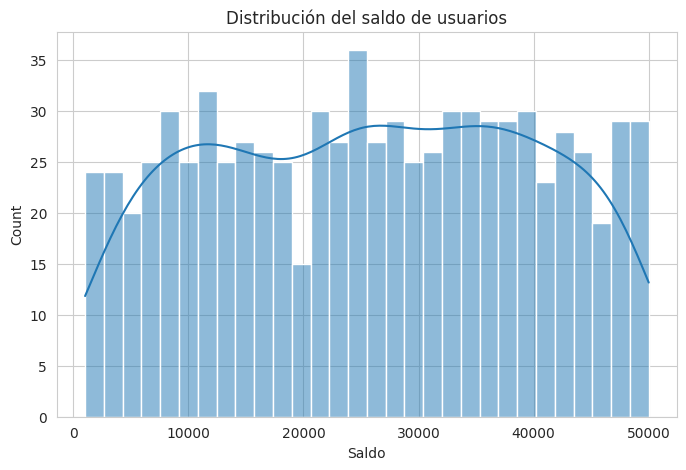

In [0]:
df_usuarios_pd = spark.sql(f"SELECT * FROM {DB}.usuario").toPandas()

plt.figure(figsize=(8,5))
sns.histplot(df_usuarios_pd['saldo'], bins=30, kde=True)
plt.title("Distribución del saldo de usuarios")
plt.xlabel("Saldo")
plt.show()


Recencia y frecuencia de apuestas por usuario (JOIN usuario–apuesta)
Esta es la más importante: aquí deberías ver claramente dos poblaciones separadas (bimodal), confirmando que el sesgo de perfil sí quedó en los datos.

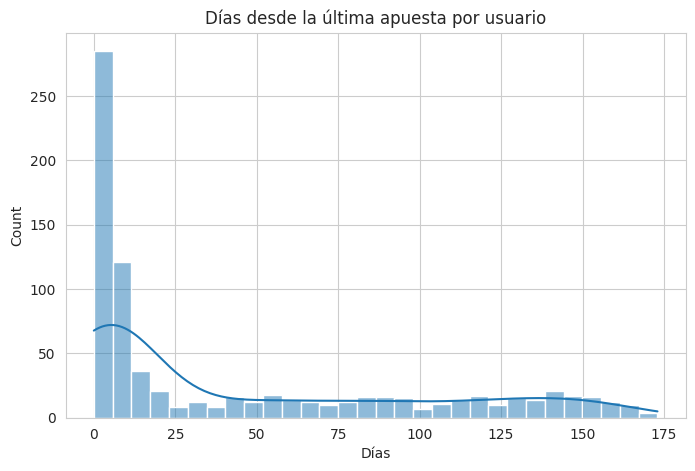

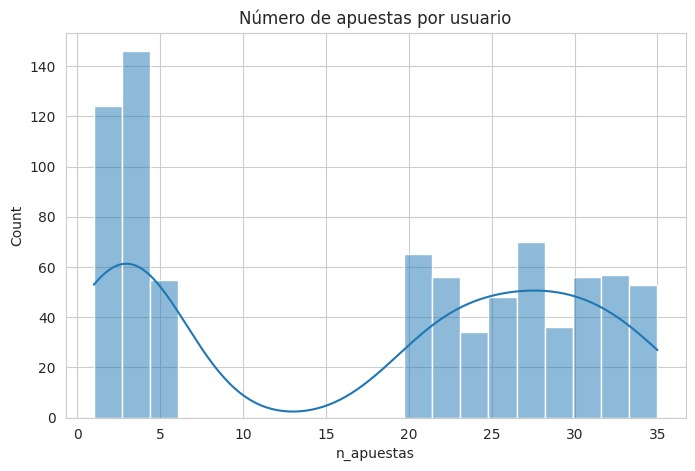

In [0]:
df_apuestas_usuario = spark.sql(f"""
    SELECT u.id_usuario,
           COUNT(a.id_apuesta) AS n_apuestas,
           DATEDIFF(CURRENT_TIMESTAMP(), MAX(a.fecha_apuesta)) AS dias_desde_ultima
    FROM {DB}.usuario u
    LEFT JOIN {DB}.apuesta a ON u.id_usuario = a.id_usuario
    GROUP BY u.id_usuario
""").toPandas()

plt.figure(figsize=(8,5))
sns.histplot(df_apuestas_usuario['dias_desde_ultima'].dropna(), bins=30, kde=True)
plt.title("Días desde la última apuesta por usuario")
plt.xlabel("Días")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df_apuestas_usuario['n_apuestas'], bins=20, kde=True)
plt.title("Número de apuestas por usuario")
plt.show()


gran cantidad de usuarios apuestan en un rango reciente de dias, mientras que otra cantidad considerable se distribuyen uniformemente hacia la derecha mostrando un comportamiento de posible des-uso de la plataforma, en el numero de apuestas por usuario, o los usuarios apuestan poco (entre dos a 5 veces) o apuestan gran cantidad de veces (entre 20 a 35 veces)

Apuestas por tipo de deporte (JOIN apuesta–evento)

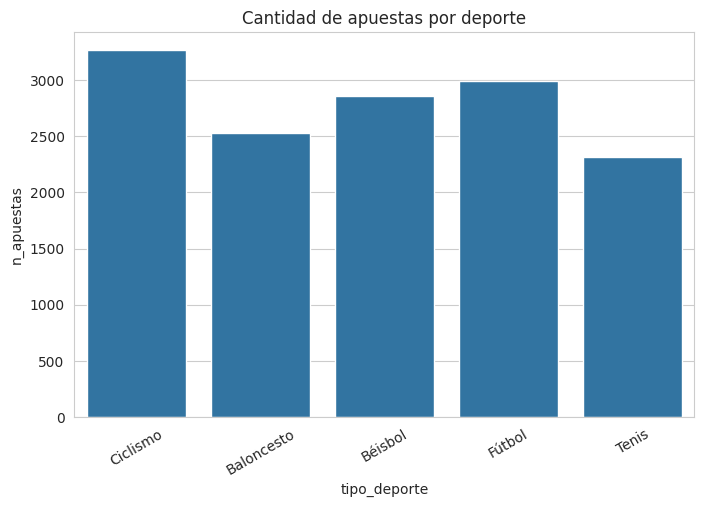

In [0]:
df_deportes = spark.sql(f"""
    SELECT e.tipo_deporte, COUNT(a.id_apuesta) AS n_apuestas, SUM(a.monto) AS monto_total
    FROM {DB}.apuesta a
    JOIN {DB}.evento e ON a.id_evento = e.id_evento
    GROUP BY e.tipo_deporte
""").toPandas()

plt.figure(figsize=(8,5))
sns.barplot(data=df_deportes, x='tipo_deporte', y='n_apuestas')
plt.title("Cantidad de apuestas por deporte")
plt.xticks(rotation=30)
plt.show()

Distribución de estados de apuesta (JOIN apuesta–estado_apuesta)

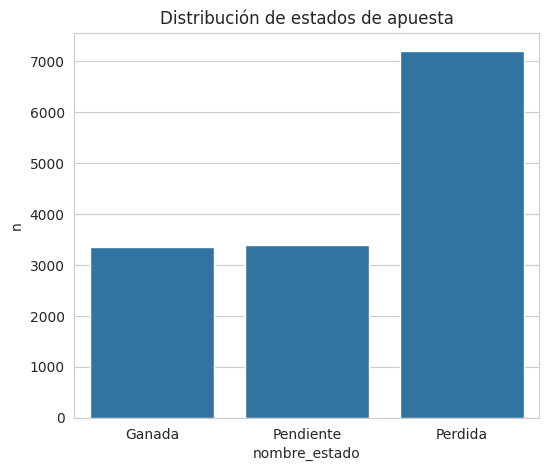

In [0]:
df_estado = spark.sql(f"""
    SELECT ea.nombre_estado, COUNT(*) AS n
    FROM {DB}.apuesta a
    JOIN {DB}.estado_apuesta ea ON a.id_estado_apuesta = ea.id_estado
    GROUP BY ea.nombre_estado
""").toPandas()

plt.figure(figsize=(6,5))
sns.barplot(data=df_estado, x='nombre_estado', y='n')
plt.title("Distribución de estados de apuesta")
plt.show()

mas del doble de apuestas son perdidas a diferencia de los estados de ganadas, es decir que muchos usuarios representan perdidas significativas dentro de la plataforma.

Tasa de pérdida por usuario (JOIN usuario–apuesta, agregado)

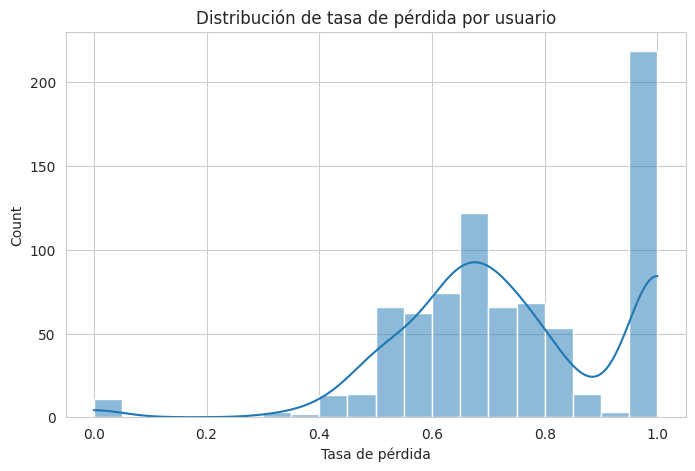

In [0]:
df_tasa_perdida = spark.sql(f"""
    SELECT u.id_usuario,
           SUM(CASE WHEN a.id_estado_apuesta = 3 THEN 1 ELSE 0 END) AS perdidas,
           SUM(CASE WHEN a.id_estado_apuesta IN (2,3) THEN 1 ELSE 0 END) AS resueltas
    FROM {DB}.usuario u
    JOIN {DB}.apuesta a ON u.id_usuario = a.id_usuario
    GROUP BY u.id_usuario
    HAVING resueltas > 0
""").toPandas()
df_tasa_perdida['tasa_perdida'] = df_tasa_perdida['perdidas'] / df_tasa_perdida['resueltas']

plt.figure(figsize=(8,5))
sns.histplot(df_tasa_perdida['tasa_perdida'], bins=20, kde=True)
plt.title("Distribución de tasa de pérdida por usuario")
plt.xlabel("Tasa de pérdida")
plt.show()

existe una brecha real entre usuarios que tienen una tasa de pérdida mayor y los que no, se visualizan dos grupos: uno alrededor de 45-55% de pérdidas, otro alrededor de 65-80%.

Montos por tipo de transacción (JOIN transaccion–usuario)

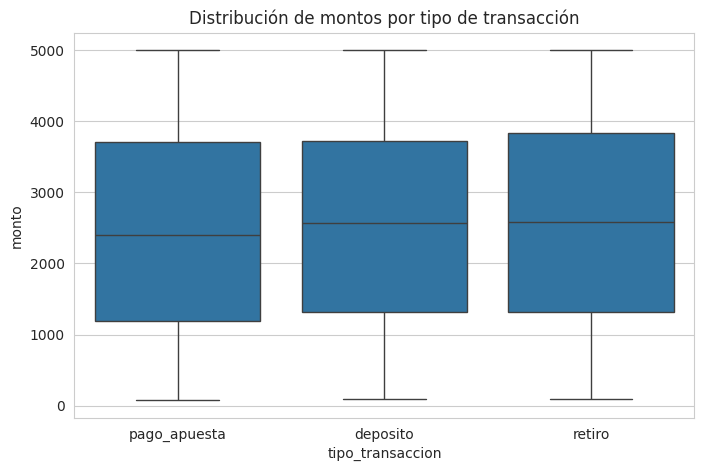

In [0]:
df_trans = spark.sql(f"""
    SELECT t.tipo_transaccion, t.monto
    FROM {DB}.transaccion t
    JOIN {DB}.usuario u ON t.id_usuario = u.id_usuario
""").toPandas()

plt.figure(figsize=(8,5))
sns.boxplot(data=df_trans, x='tipo_transaccion', y='monto')
plt.title("Distribución de montos por tipo de transacción")
plt.show()

Análisis Temporal (Evolución de apuestas/monto por fecha)

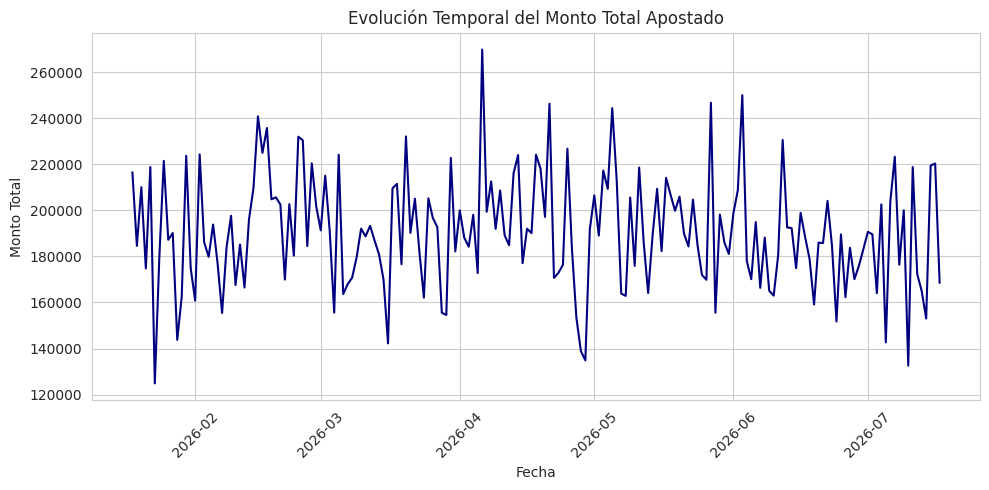

In [0]:


df_temporal = spark.sql(f"""
    SELECT DATE(fecha_apuesta) AS fecha, SUM(monto) AS monto_total
    FROM {DB}.apuesta
    GROUP BY DATE(fecha_apuesta)
    ORDER BY fecha
""").toPandas()

plt.figure(figsize=(10,5))
sns.lineplot(data=df_temporal, x="fecha", y="monto_total", color="navy")
plt.title("Evolución Temporal del Monto Total Apostado")
plt.xlabel("Fecha")
plt.ylabel("Monto Total")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

 Distribución Logarítmica para Variables Sesgadas (Saldo/Monto)

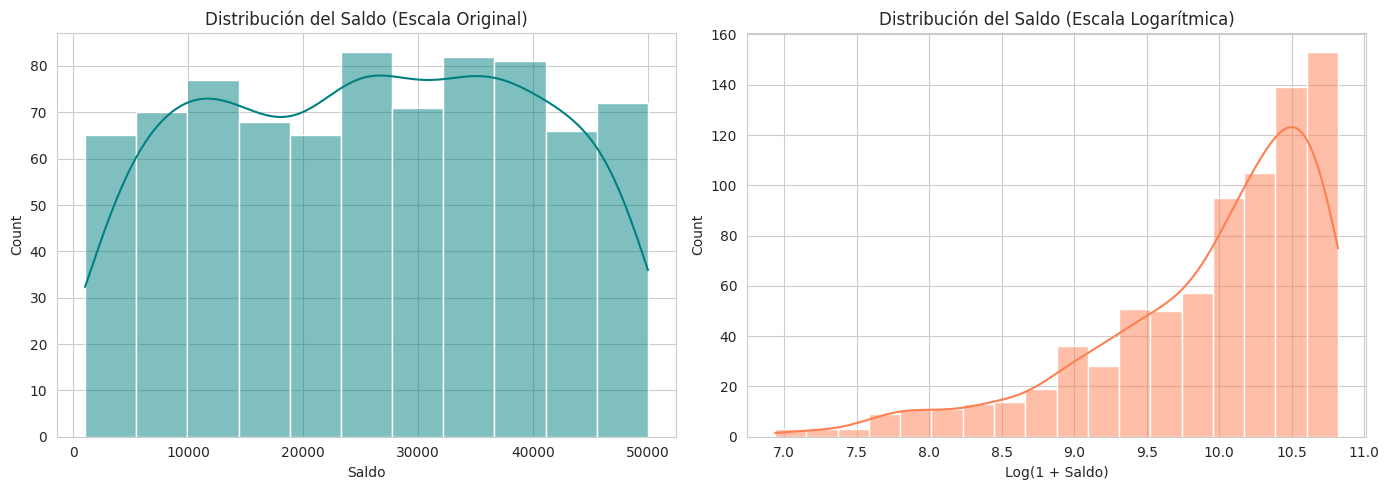

In [0]:

import numpy as np

df_saldo = spark.sql(f"SELECT saldo FROM {DB}.usuario").toPandas()
df_saldo["saldo"] = df_saldo["saldo"].astype(float)
df_saldo["saldo_log"] = np.log1p(df_saldo["saldo"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Escala original
sns.histplot(df_saldo["saldo"], kde=True, ax=axes[0], color="teal")
axes[0].set_title("Distribución del Saldo (Escala Original)")
axes[0].set_xlabel("Saldo")

# Escala logarítmica
sns.histplot(df_saldo["saldo_log"], kde=True, ax=axes[1], color="coral")
axes[1].set_title("Distribución del Saldo (Escala Logarítmica)")
axes[1].set_xlabel("Log(1 + Saldo)")

plt.tight_layout()
plt.show()